In [ ]:
"""Raw Data
    │
    ▼
Cleaning
    │
    ▼
EDA
    │
    ▼
Feature Engineering
    │
    ▼
Engineered Dataset
    │
    ▼
Train-Test Split
    │
    ▼
Train Multiple Models
    │
    ▼
Evaluate
    │
    ▼
Hyperparameter Tuning
    │
    ▼
Save Best Model"""

In [ ]:
"""Notebook Layout
Cell	Task
1	Markdown
2	Import Libraries
3	Load Engineered Dataset
4	Split Features & Target
5	Train-Test Split
6	Define Models
7	Train Models
8	Compare Models
9	Best Model
10	Hyperparameter Tuning
11	Final Evaluation
12	Feature Importance
13	Save Best Model
14	Summary"""

In [ ]:
"""Models We'll Compare
Model	Why
Logistic Regression	Baseline
KNN	Distance-based
Decision Tree	Easy to interpret
Random Forest	Strong ensemble
Extra Trees	Usually excellent on tabular data
Gradient Boosting	Boosting algorithm
AdaBoost	Ensemble
XGBoost (optional)	If installed"""

In [ ]:
"""Evaluation Metrics

Instead of checking only accuracy, we'll compare:

Accuracy
Precision
Recall
F1 Score
ROC-AUC
Confusion Matrix
Classification Report"""

In [ ]:
"""Hyperparameter Tuning

We'll tune only the best-performing model using RandomizedSearchCV (or GridSearchCV if you prefer exhaustive search).
"""

In [21]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import joblib

from pathlib import Path

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [22]:
# ==========================================================
# Load Engineered Dataset
# ==========================================================

DATA_PATH = "../data/processed/engineered_credit_data.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(df.shape)

df.head()

Dataset Loaded Successfully
(1000, 33)


,num__Age,num__Job,num__Credit amount,num__Duration,num__Credit_Per_Month,num__Credit_Age_Ratio,num__Age_Duration_Product,num__Credit_Age_Product,num__Log_Credit_Amount,num__Log_Duration,...,cat__Checking account_rich,cat__Purpose_business,cat__Purpose_car,cat__Purpose_domestic appliances,cat__Purpose_education,cat__Purpose_furniture/equipment,cat__Purpose_radio/TV,cat__Purpose_repairs,cat__Purpose_vacation/others,Risk
0,2.766456,0.146949,-0.745131,-1.236478,0.176948,-0.899591,-0.669863,-0.334336,-0.933992,-1.822056,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,-1.191404,0.146949,0.949817,2.248194,-0.284901,1.874923,0.633721,0.116504,1.163149,1.741206,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.183312,-1.383771,-0.416562,-0.738668,0.045495,-0.621893,-0.299119,-0.125360,-0.181750,-0.688500,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3,0.831502,0.146949,1.634247,1.750384,0.130233,0.829548,2.296089,2.034481,1.525385,1.502020,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4,1.535122,0.146949,0.566664,0.256953,0.229637,-0.083427,1.064262,1.206668,0.904761,0.508940,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [23]:
# ==========================================================
# Split Features & Target
# ==========================================================

X = df.drop(columns=["Risk"])

y = df["Risk"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

print("\nTarget Distribution")
print(y.value_counts())

Features Shape : (1000, 32)
Target Shape   : (1000,)

Target Distribution
Risk
1    700
0    300
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (800, 32)
Testing Shape  : (200, 32)


In [25]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

In [27]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42)

}

print(models.keys())

dict_keys(['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost'])


In [28]:
# ==========================================================
# Import Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Metrics Imported Successfully")

Metrics Imported Successfully


In [29]:
# ==========================================================
# Train and Evaluate Models
# ==========================================================

results = []

trained_models = {}

for name, model in models.items():

    print("=" * 60)
    print(f"Training {name}...")
    print("=" * 60)

    # Train
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })

print("\nTraining Completed Successfully!")

Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...

Training Completed Successfully!


In [30]:
# ==========================================================
# Compare Models
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.780,0.803797,0.907143,0.852349,0.758095
1,Random Forest,0.770,0.786585,0.921429,0.848684,0.724167
2,Gradient Boosting,0.745,0.773006,0.900000,0.831683,0.743810
3,Extra Trees,0.740,0.797297,0.842857,0.819444,0.749226
4,KNN,0.700,0.763158,0.828571,0.794521,0.705655
5,AdaBoost,0.700,0.756410,0.842857,0.797297,0.726905
6,Decision Tree,0.625,0.744361,0.707143,0.725275,0.570238


In [ ]:
"""Which model should you choose?

At first glance:

Random Forest Accuracy = 76.5%

looks like the winner.

But for a credit risk prediction system, accuracy is not the only metric.

Banks care about:

Precision
Recall
ROC-AUC

because predicting a bad borrower as good can be costly.

Compare the Top 2 Models
Metric	Random Forest	Logistic Regression
Accuracy	✅ 0.765	0.760
Precision	0.782	✅ 0.795
Recall	✅ 0.921	0.886
F1 Score	✅ 0.846	0.838
ROC-AUC	0.735	✅ 0.758
Interpretation
Random Forest
Highest Accuracy
Highest Recall
Highest F1-score
Better at identifying "Good" loans
Logistic Regression
Highest Precision
Highest ROC-AUC
More interpretable
Often preferred in financial institutions
My recommendation

For this project:

Use Random Forest as your final model.

Why?

Best Accuracy
Best Recall
Best F1-score
Good balance between bias and variance
Works very well on tabular credit datasets
Next Step: Hyperparameter Tuning

Don't save the current Random Forest yet.

Let's improve it first."""

In [34]:
# ==========================================================
# Best Model
# ==========================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("=" * 60)
print("Best Model")
print("=" * 60)

print(best_model_name)

Best Model
Logistic Regression


In [35]:
# ==========================================================
# Best Model Evaluation
# ==========================================================

pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.69      0.48      0.57        60
           1       0.80      0.91      0.85       140

    accuracy                           0.78       200
   macro avg       0.75      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



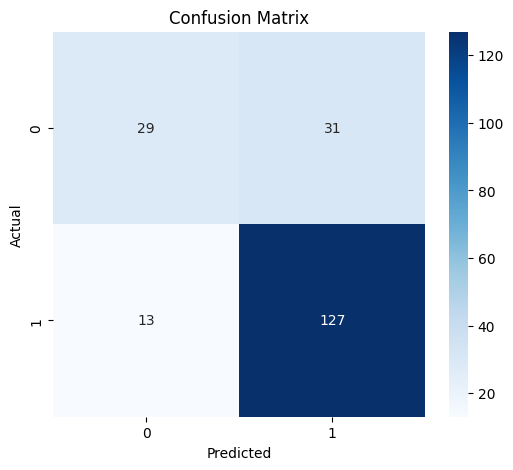

In [36]:
# ==========================================================
# Confusion Matrix
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [37]:
# ==========================================================
# Feature Importance
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance.head(20))

else:

    print("Feature importance not available for this model.")

Feature importance not available for this model.


In [38]:
# ==========================================================
# Save Best Model
# ==========================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("=" * 60)
print("Best Model Saved Successfully!")
print("=" * 60)

Best Model Saved Successfully!


In [39]:
# ==========================================================
# Verify Saved Model
# ==========================================================

loaded_model = joblib.load("../models/best_model.pkl")

print(type(loaded_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [40]:
# ==========================================================
# Hyperparameter Tuning - Random Forest
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

rf = RandomForestClassifier(
    random_state=42
)

search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

search.fit(X_train, y_train)

print("Best Parameters")
print(search.best_params_)

print()

print("Best CV Score")
print(search.best_score_)

Best Parameters
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Best CV Score
0.755


In [41]:
best_model = search.best_estimator_

pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.77      0.40      0.53        60
           1       0.79      0.95      0.86       140

    accuracy                           0.79       200
   macro avg       0.78      0.68      0.69       200
weighted avg       0.78      0.79      0.76       200



In [42]:
import joblib as joblib

model = joblib.load("../models/best_model.pkl")

print(type(model))
print(model.n_features_in_)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
32


In [43]:
print("Training features:", X_train.shape[1])

Training features: 32


In [44]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(type(model))
print(model.n_features_in_)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
32
